# 策略房数据分析

# 火系测试_全空

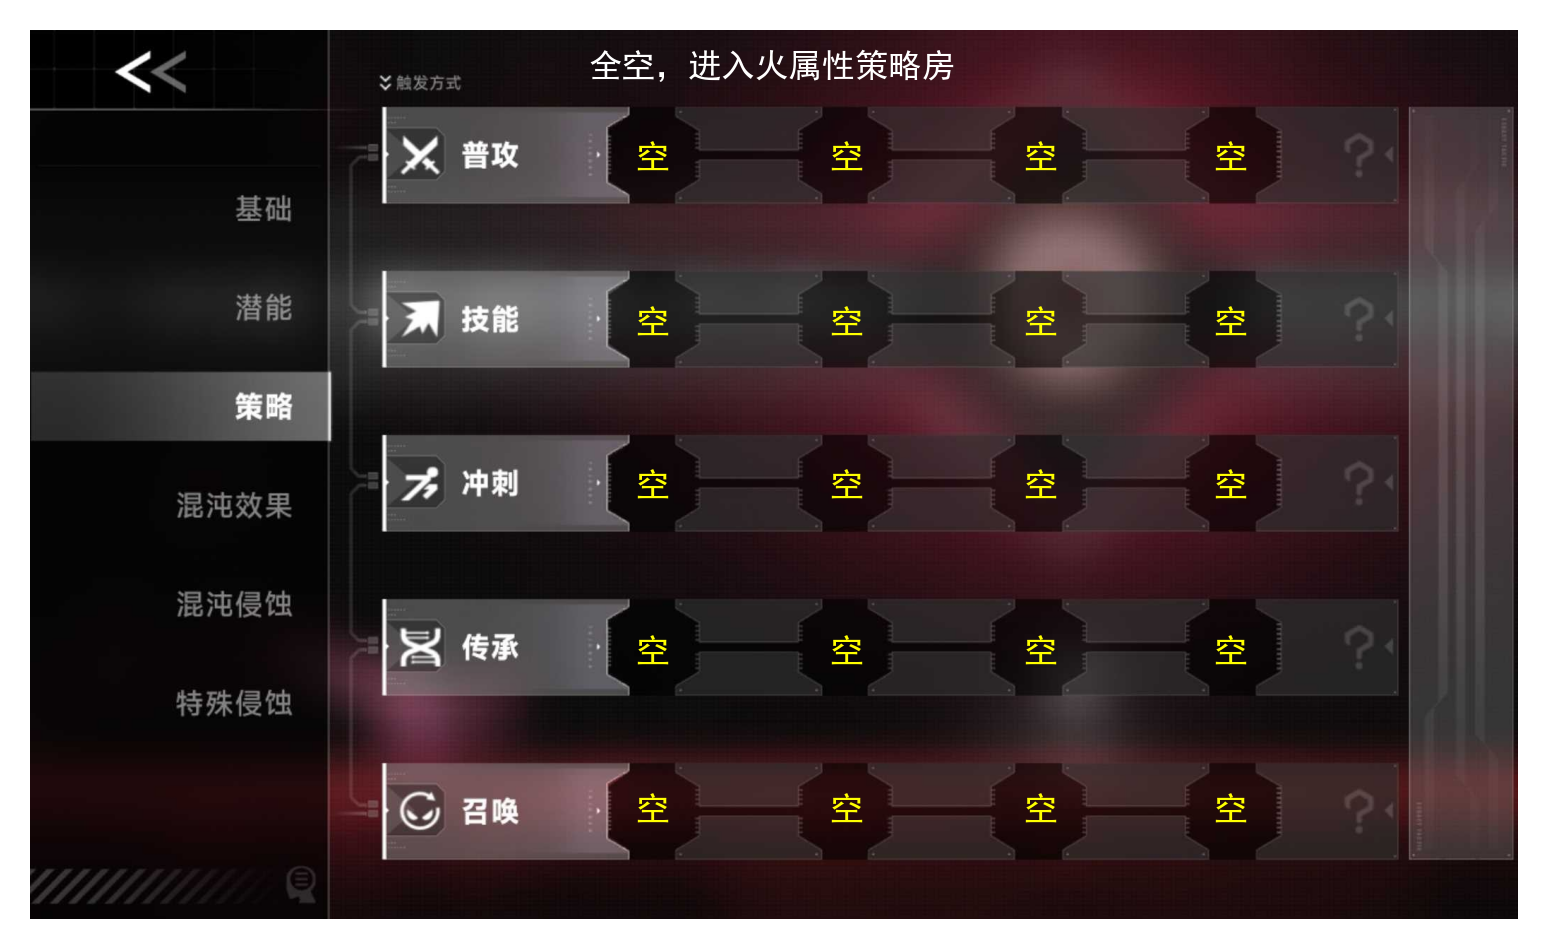

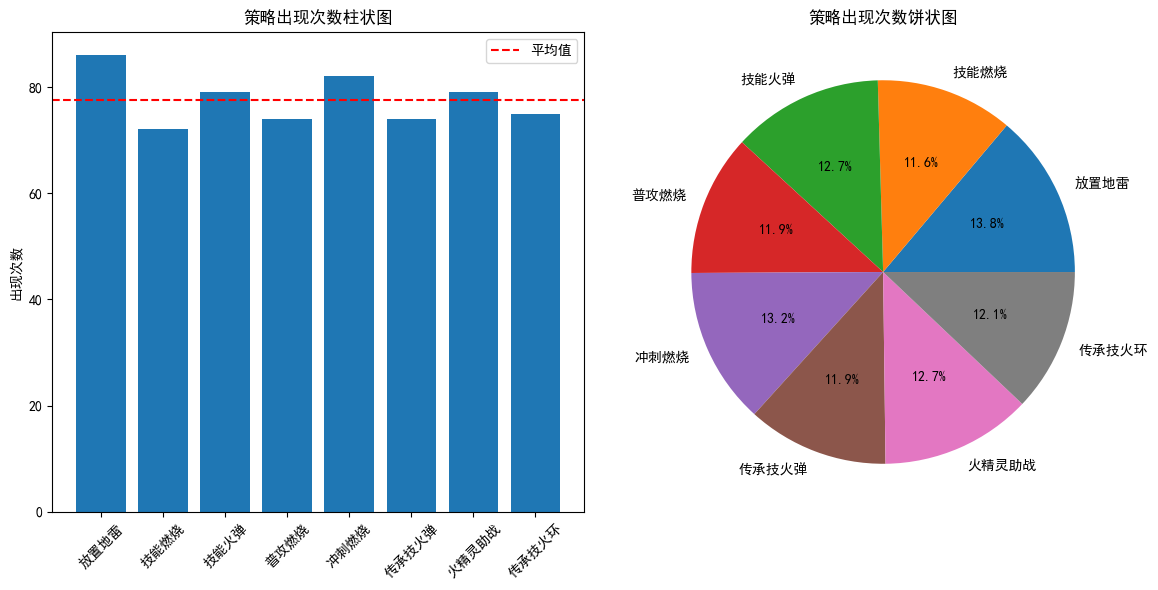

卡方统计量: 2.033816425120773, p 值: 0.9579449970672709
数据可能来自均匀分布或离散型概率分布


In [1]:
from collections import Counter
from itertools import chain
import utils


current_strategies, strategies = utils.parse_file("data/策略房/火系测试_全空.txt")
strategies = list(chain(*strategies))
utils.draw_status('全空，进入火属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

> 插入一条概率论与数理统计的知识（AI生成）
>
> 用初中生都能听懂的话介绍一下卡方和p值的意义，简短一点
>
> 卡方是用来衡量实际情况和我们假设的情况之间差别的一个数。卡方值越大，说明实际和假设的差别越大。
P 值是在假设成立的情况下，出现像我们观察到的这么大差异或者更大差异的概率。如果 P 值很小，就说明在假设成立的条件下，出现这样的结果很罕见，所以我们就倾向于认为原来的假设不对，从而拒绝原假设。

省流：卡方越小越好、p值越大越好。

# 特例：第二刷会出现一个冲突位，这很可能是个BUG

![](img/策略房BUG.gif)

# 提出猜想：各个可获得策略的概率是一致的

# 扩展场景：同一个位置的两个替换策略是否遵循该规律？

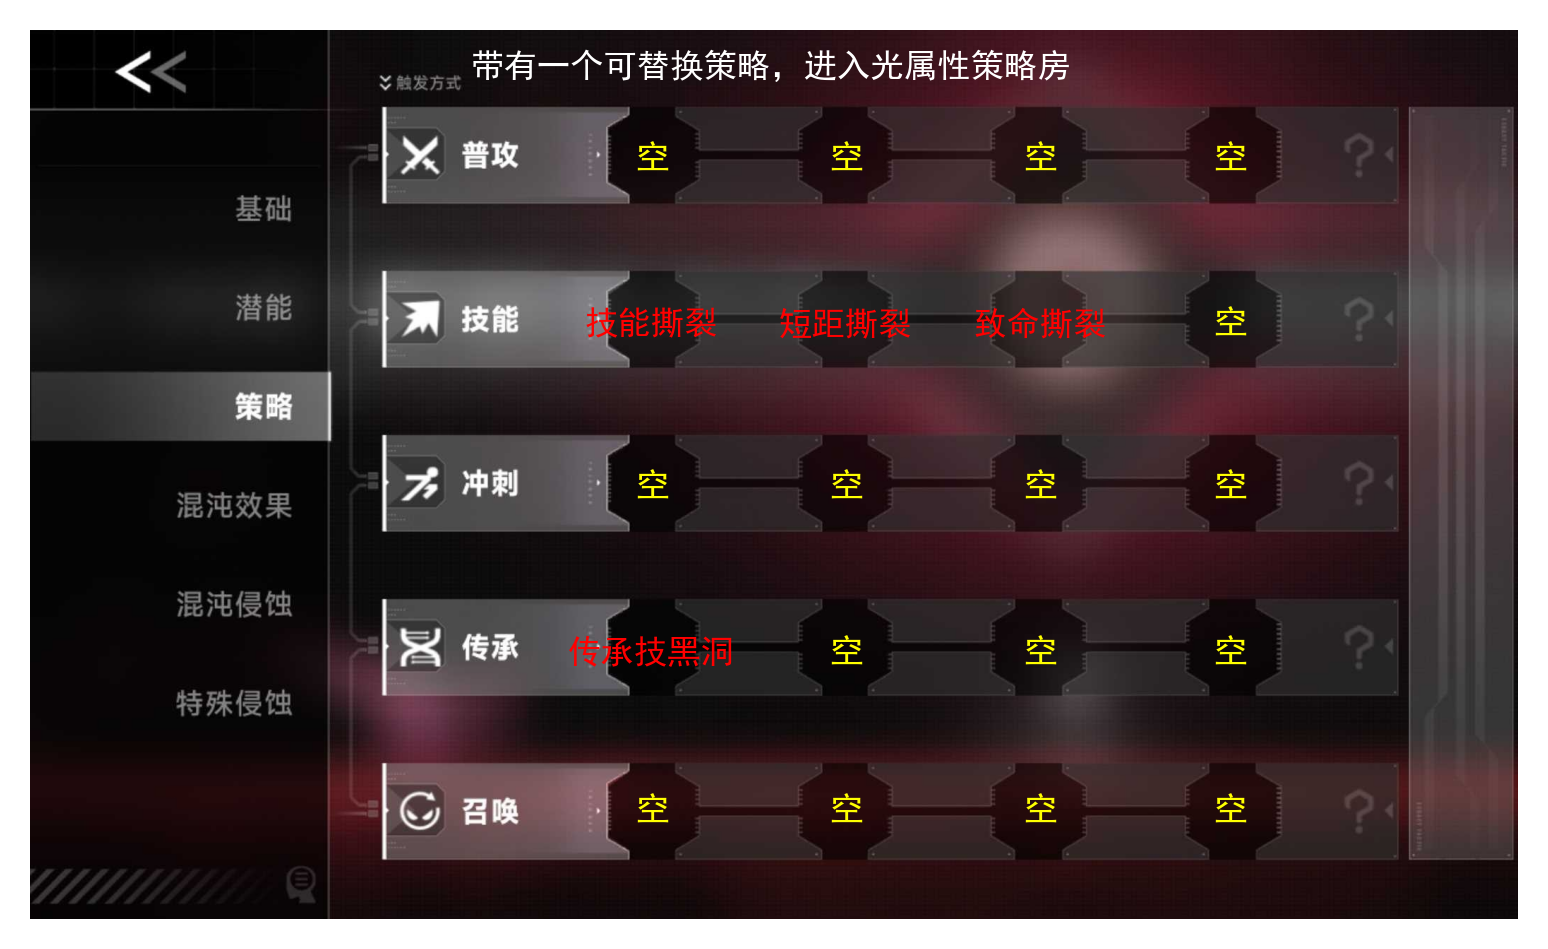

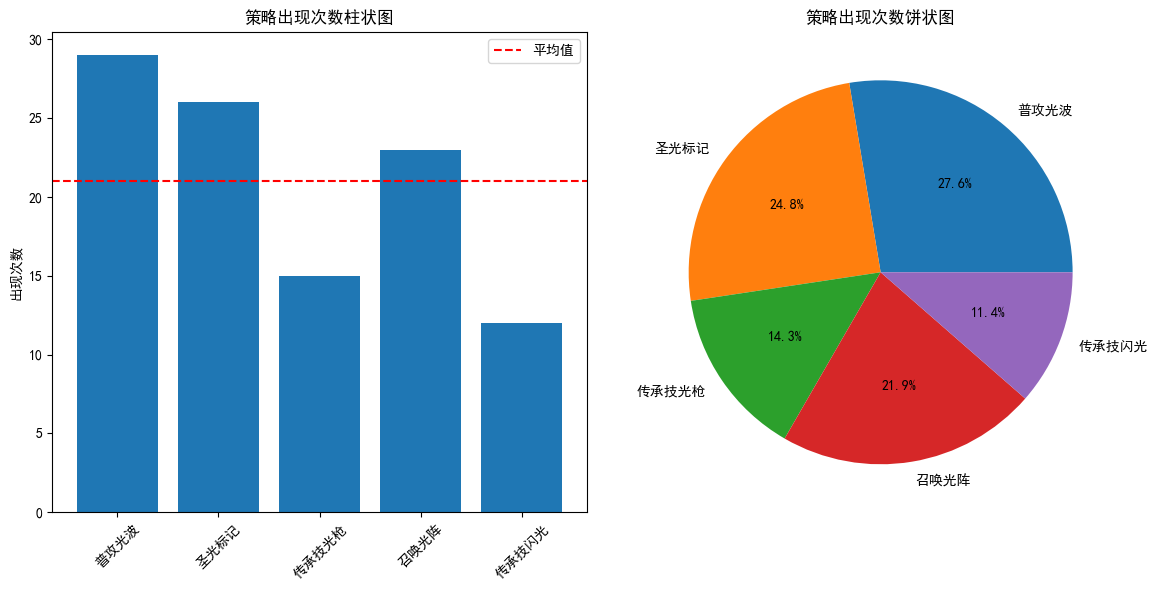

卡方统计量: 10.0, p 值: 0.04042768199451279
数据不太可能来自均匀分布或离散型概率分布。


In [2]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_1个覆盖3个基础.txt")
strategies = list(chain(*strategies))
utils.draw_status('带有一个可替换策略，进入光属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 注意到 传承技光枪和传承技闪光 的概率是其他策略的一半
# 修正猜想：可替换的策略作为一个整体加入卡池，且内部概率相等

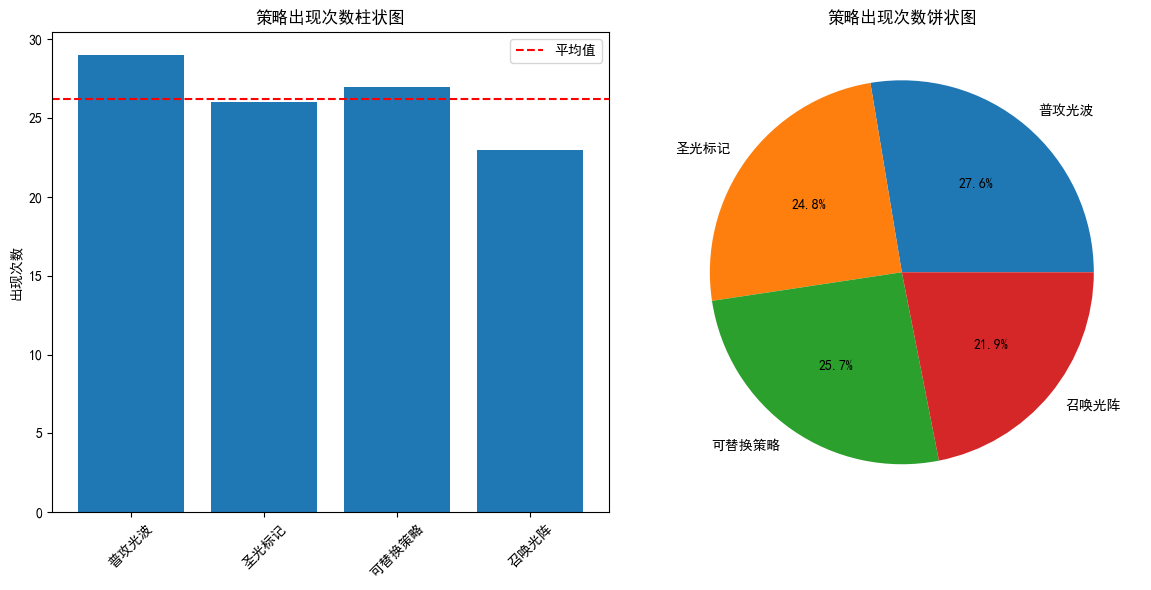

卡方统计量: 0.7142857142857142, p 值: 0.8698387717651157
数据可能来自均匀分布或离散型概率分布


In [3]:
names = [x.name for x in strategies]
names = ["可替换策略" if x.startswith('传承技') else x for x in names]
utils.plot_element_count(names)
chi2, p = utils.test_uniform_distribution(list(Counter(names).values()))

# 扩展场景：多个位置均存在可替换策略，概率分布是什么样的

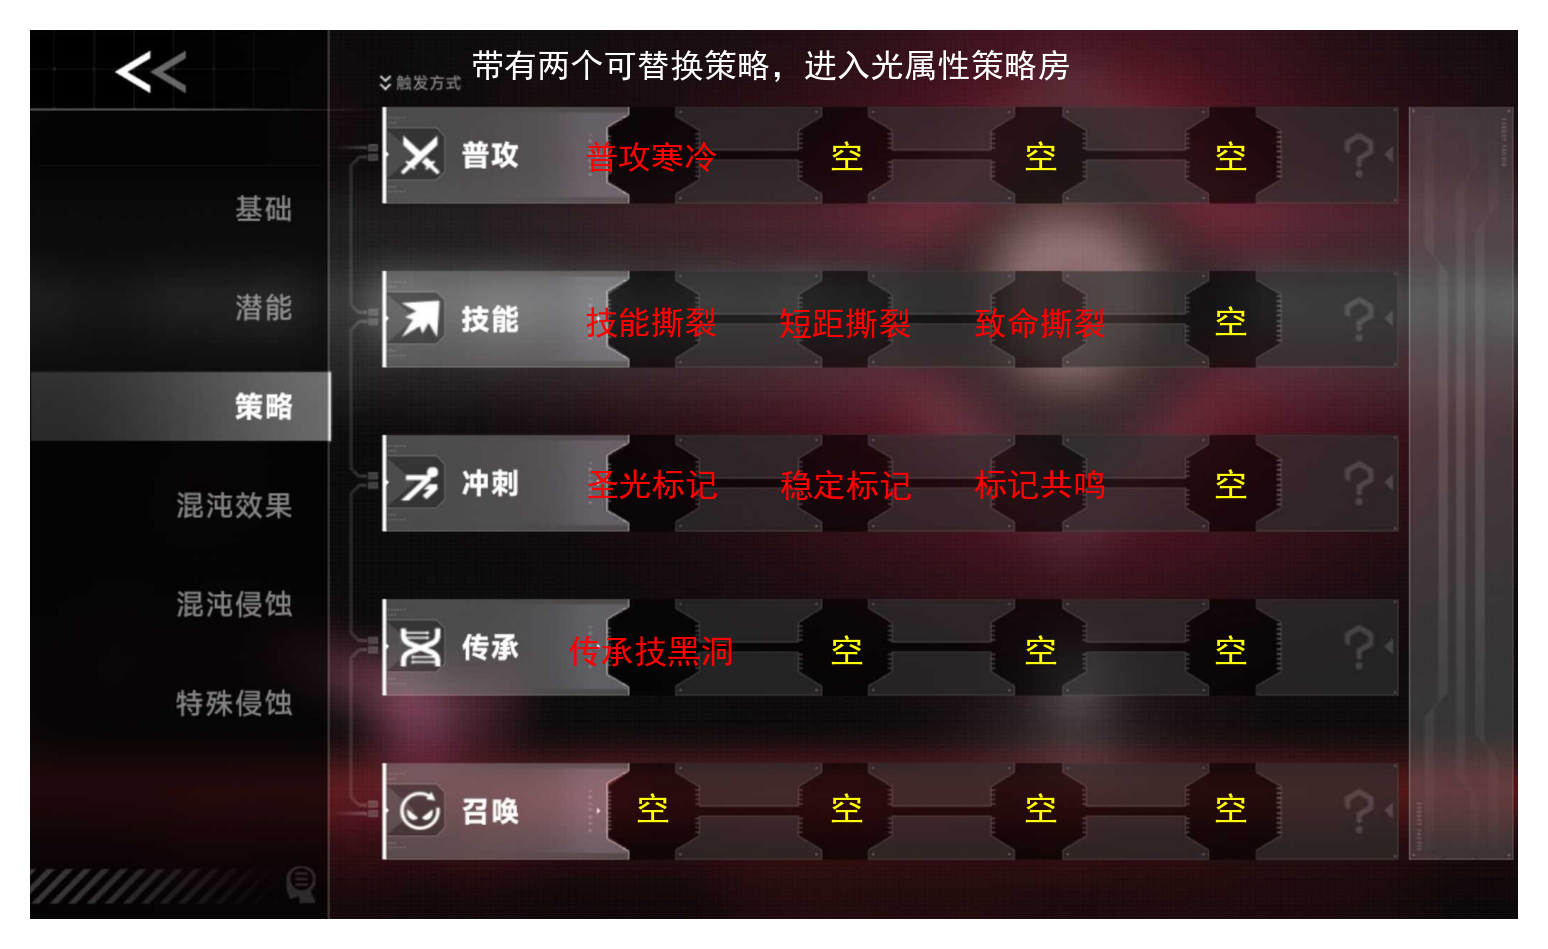

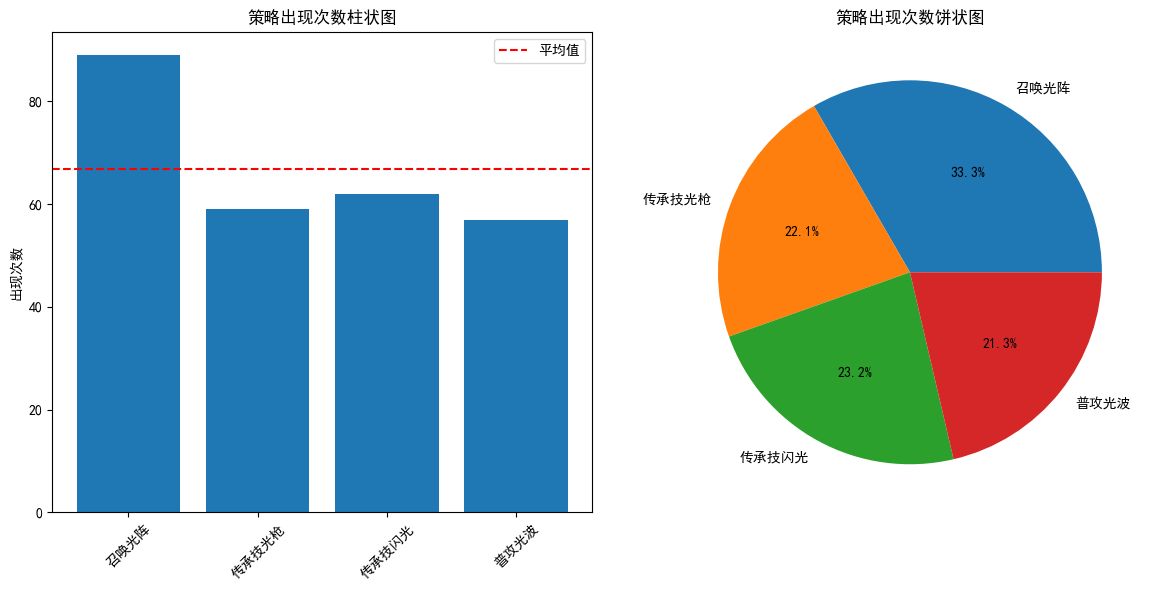

卡方统计量: 10.07865168539326, p 值: 0.017909263691730435
数据不太可能来自均匀分布或离散型概率分布。


In [4]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_2个覆盖1个基础.txt")
strategies = list(chain(*strategies))
utils.draw_status('带有两个可替换策略，进入光属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

共有89组数据。

策略池中只有4个策略，1个基础策略 \[召唤光阵\]，共出现89次，每一抽都会出现，因此它的概率是100%。

3个可替换策略，每一抽都只出现其中的2个，因此各自出现的概率是66%，平分200%。

# 修正猜想：如果可获得策略的数量为1，则剩余两个位置均为可替换策略，且平分概率

# 扩展场景：暗系是否遵循该规律

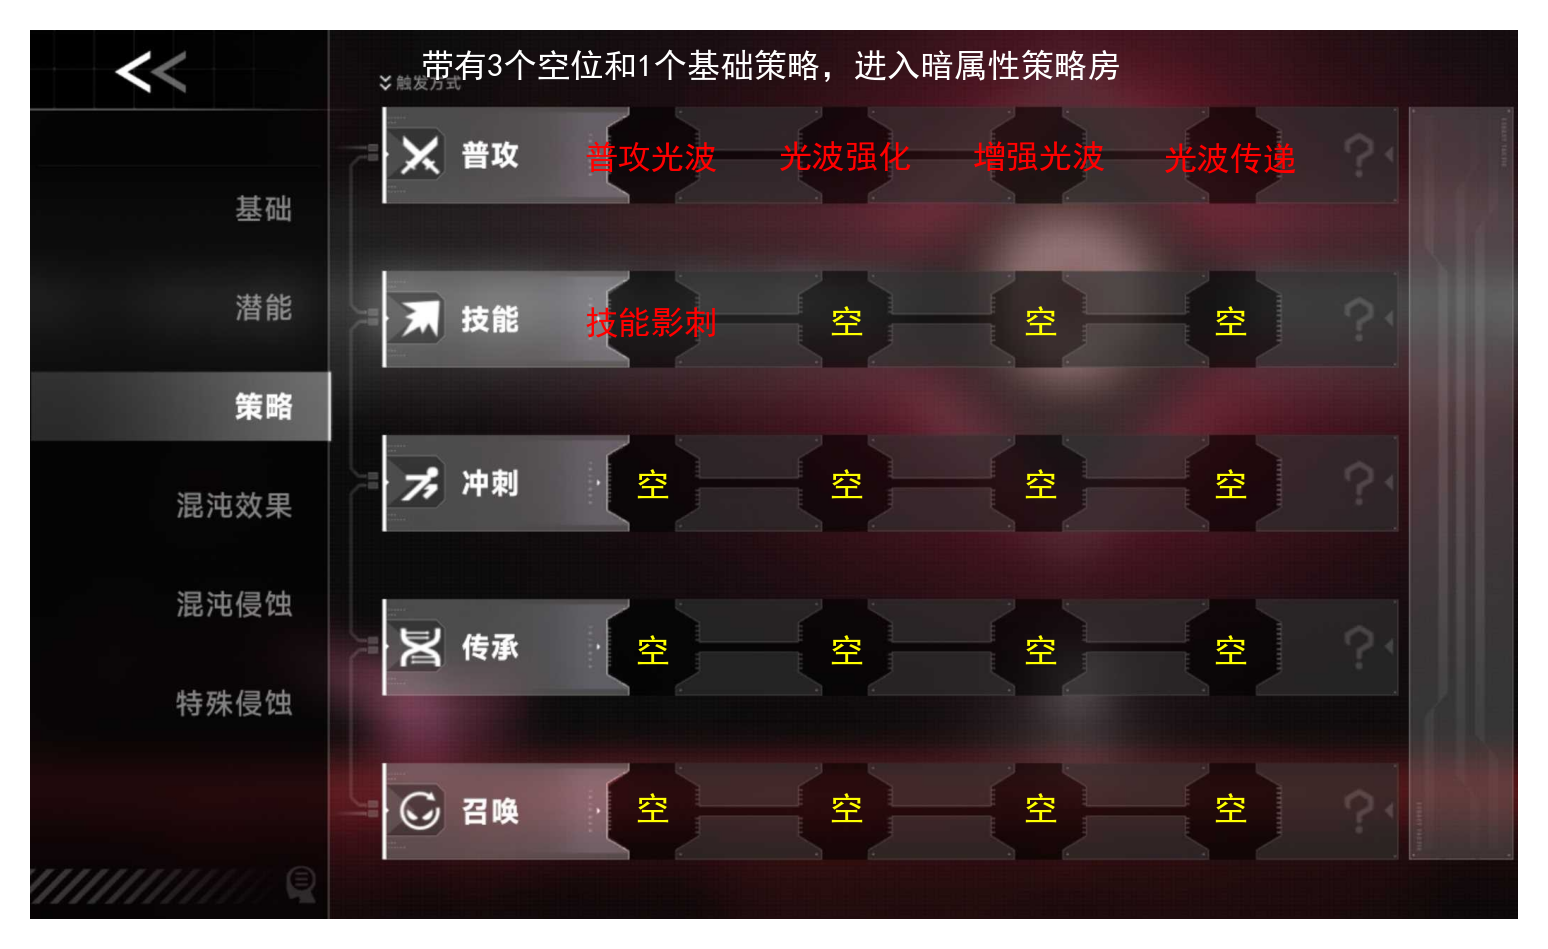

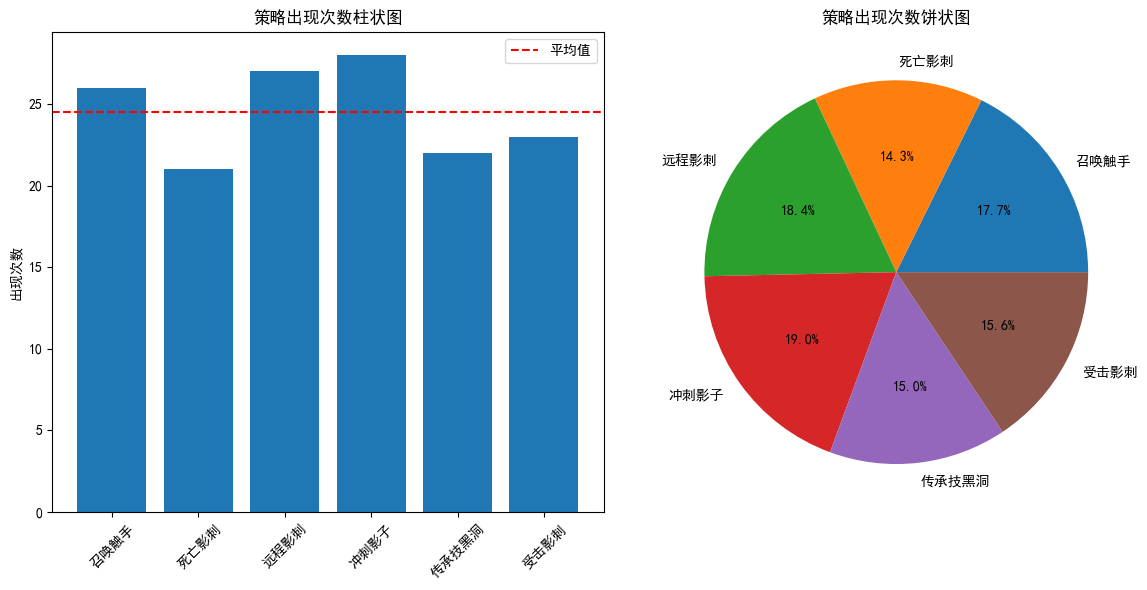

卡方统计量: 1.693877551020408, p 值: 0.889670179264078
数据可能来自均匀分布或离散型概率分布


In [5]:
current_strategies, strategies = utils.parse_file("data/策略房/暗系测试_3个基础1个一阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带有3个空位和1个基础策略，进入暗属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 暗系遵循规律，继续验证...

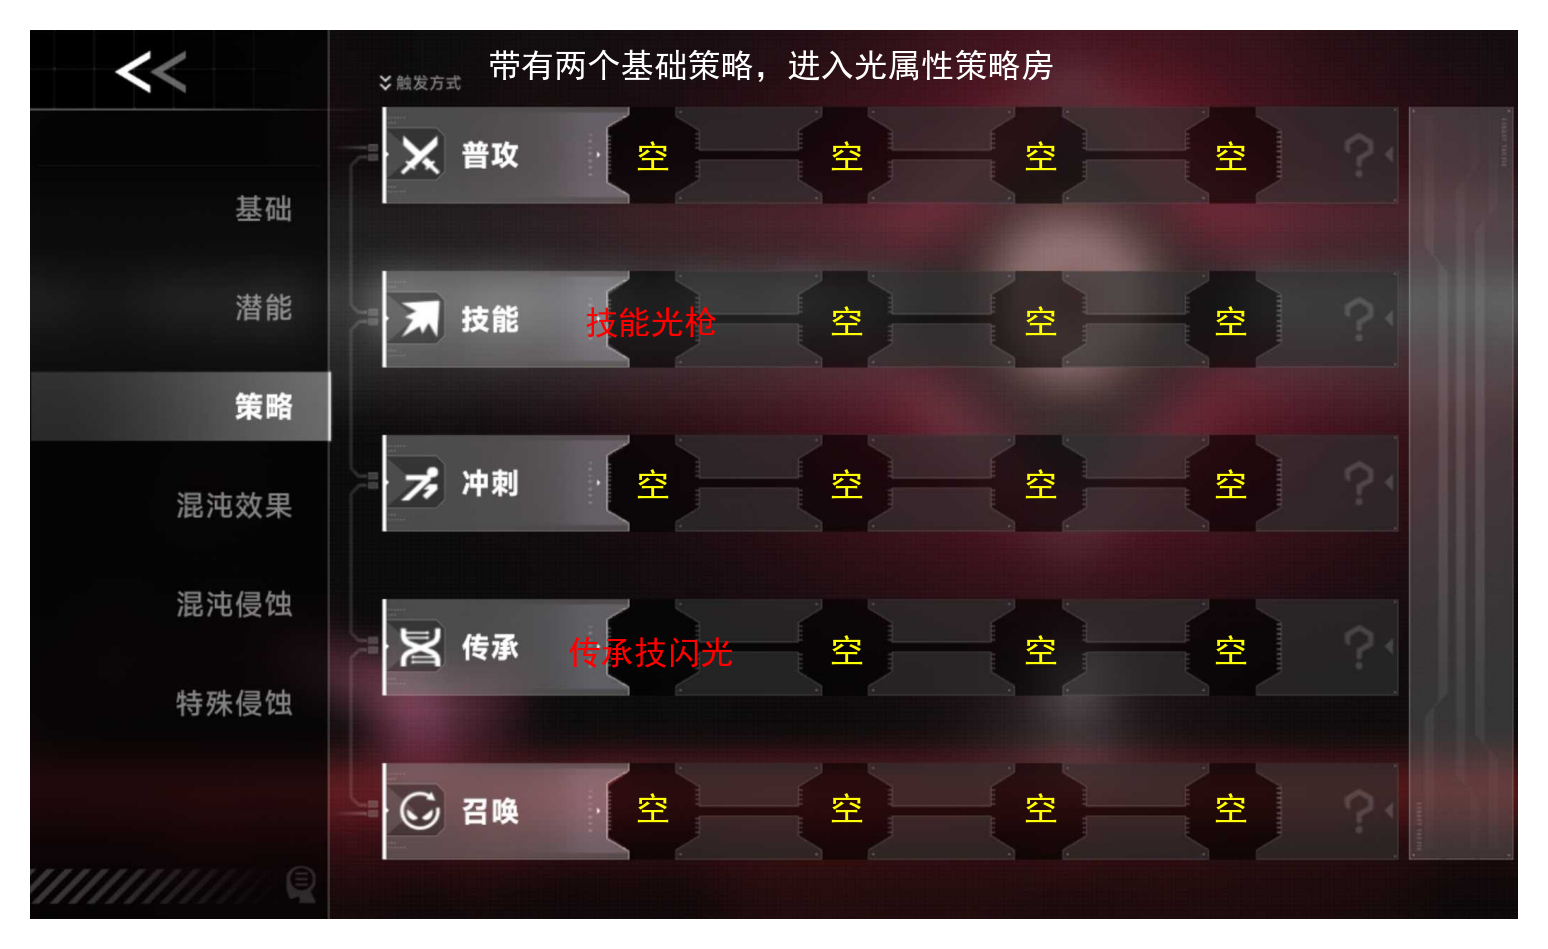

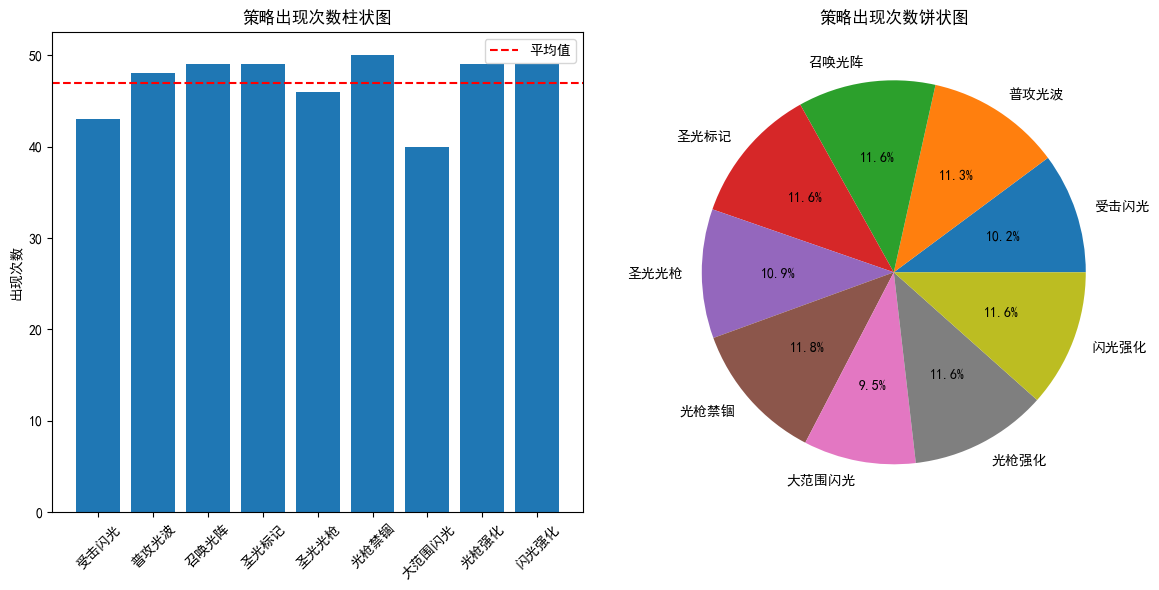

卡方统计量: 1.9574468085106382, p 值: 0.9822887245645483
数据可能来自均匀分布或离散型概率分布


In [6]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_3个基础2个一阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带有两个基础策略，进入光属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 继续验证...

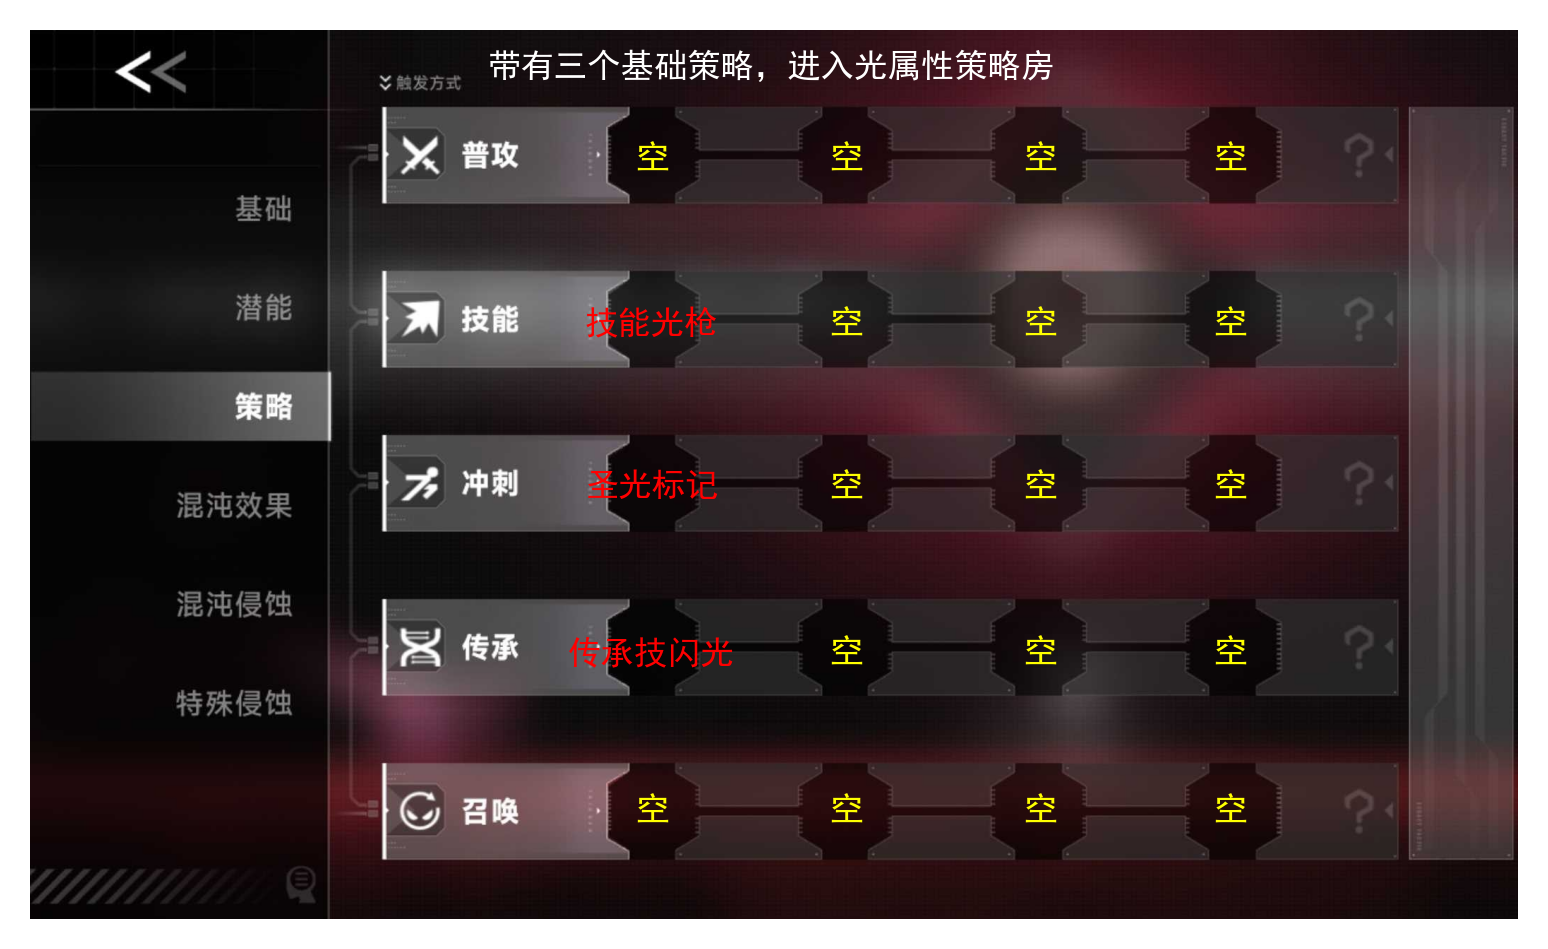

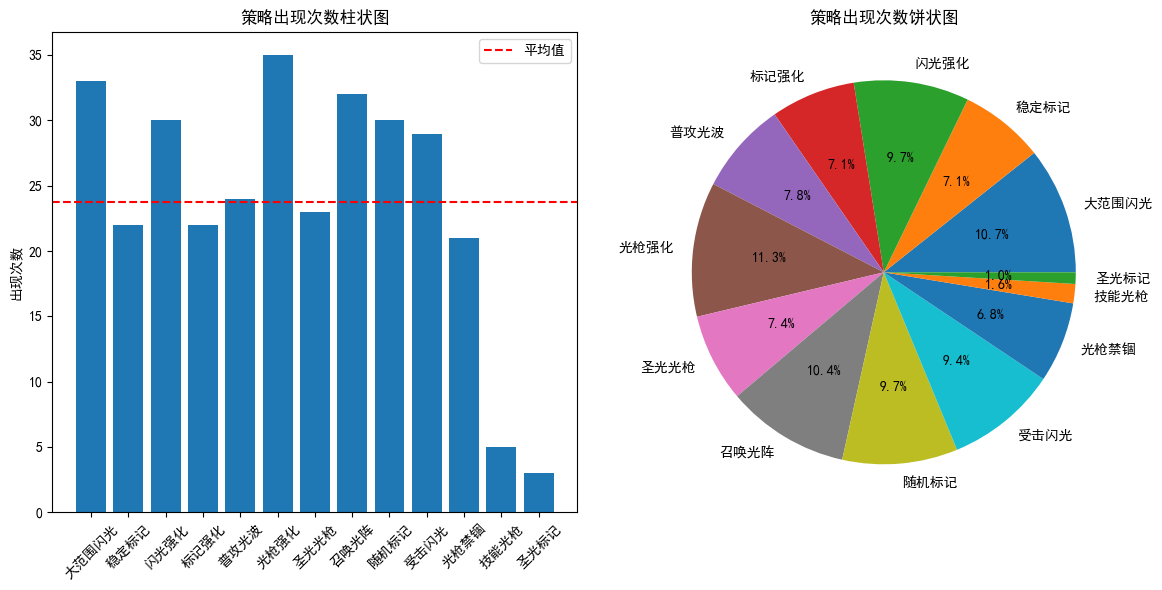

卡方统计量: 49.74110032362459, p 值: 1.5512573311271182e-06
数据不太可能来自均匀分布或离散型概率分布。


In [7]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_2个基础3个一阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带有三个基础策略，进入光属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

经观测，少量的 技能光枪 和 圣光标记 是升级，剔除出数据集。

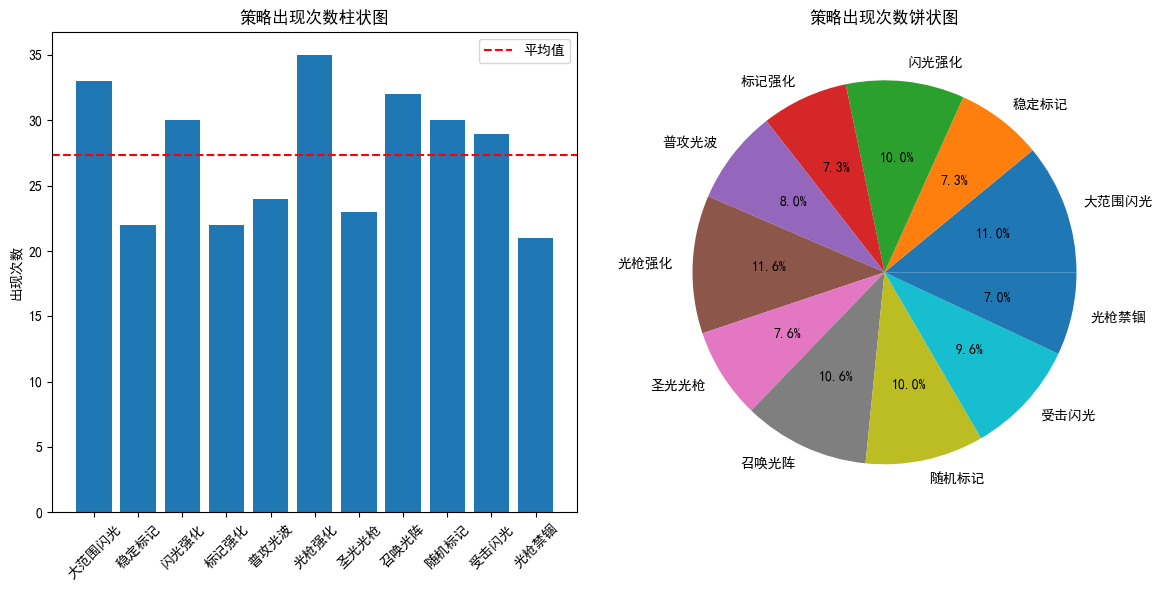

剔除策略升级
卡方统计量: 9.375415282392026, p 值: 0.4968840248490679
数据可能来自均匀分布或离散型概率分布


In [8]:
current_strategies = list(chain(*current_strategies))
names = [x.name for x in strategies if x.name not in current_strategies]
utils.plot_element_count(names)
print("剔除策略升级")
chi2, p = utils.test_uniform_distribution(list(Counter(names).values()))

# 继续验证...

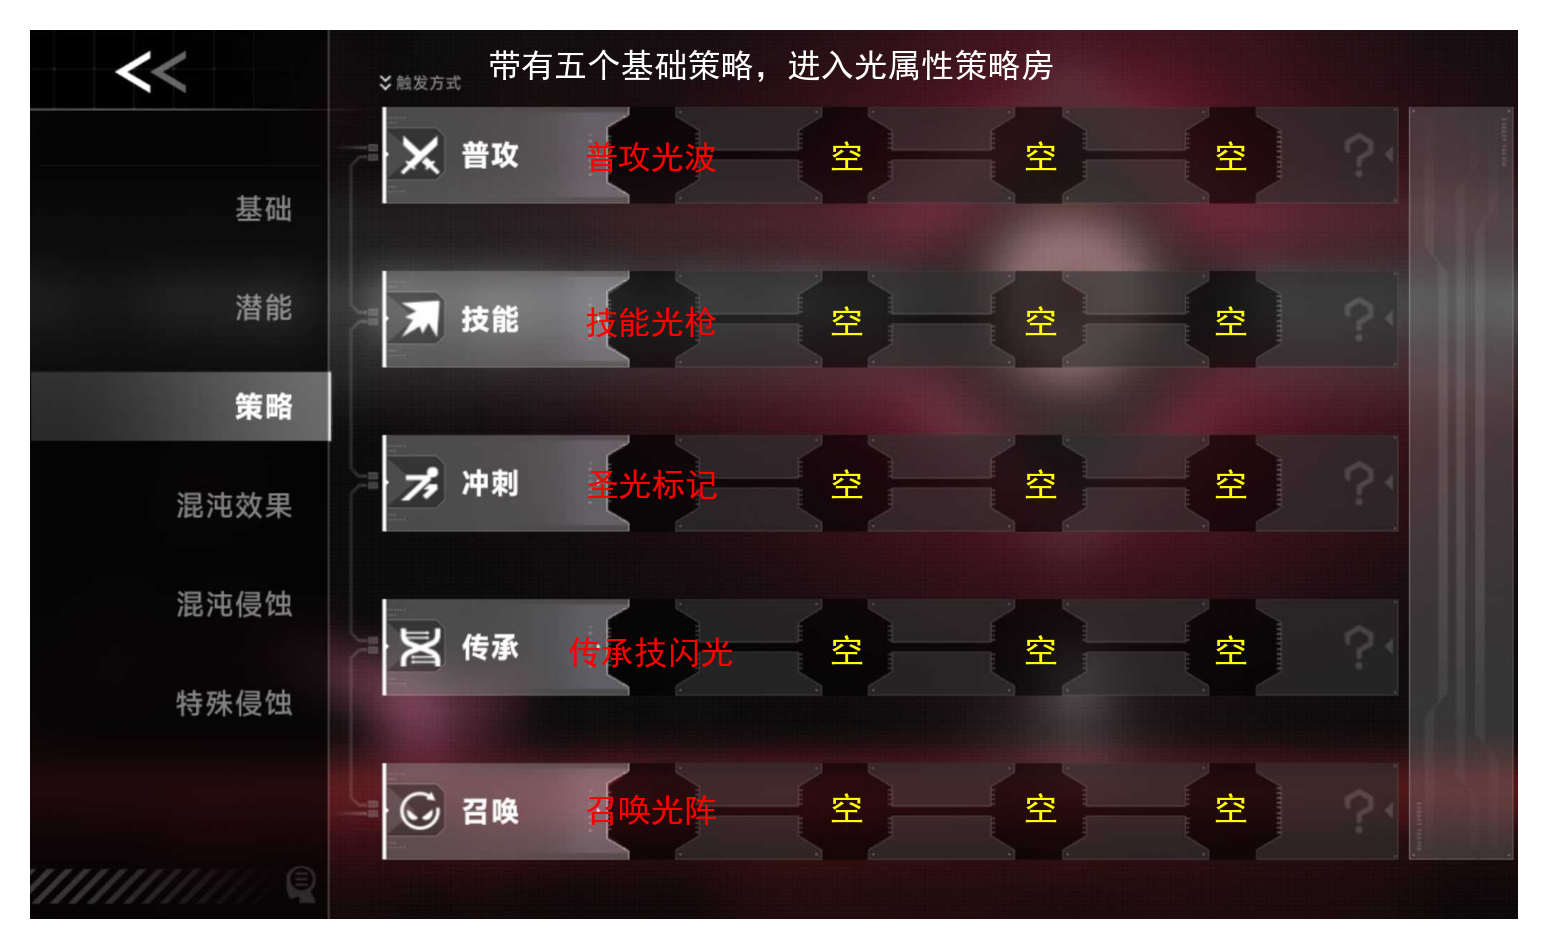

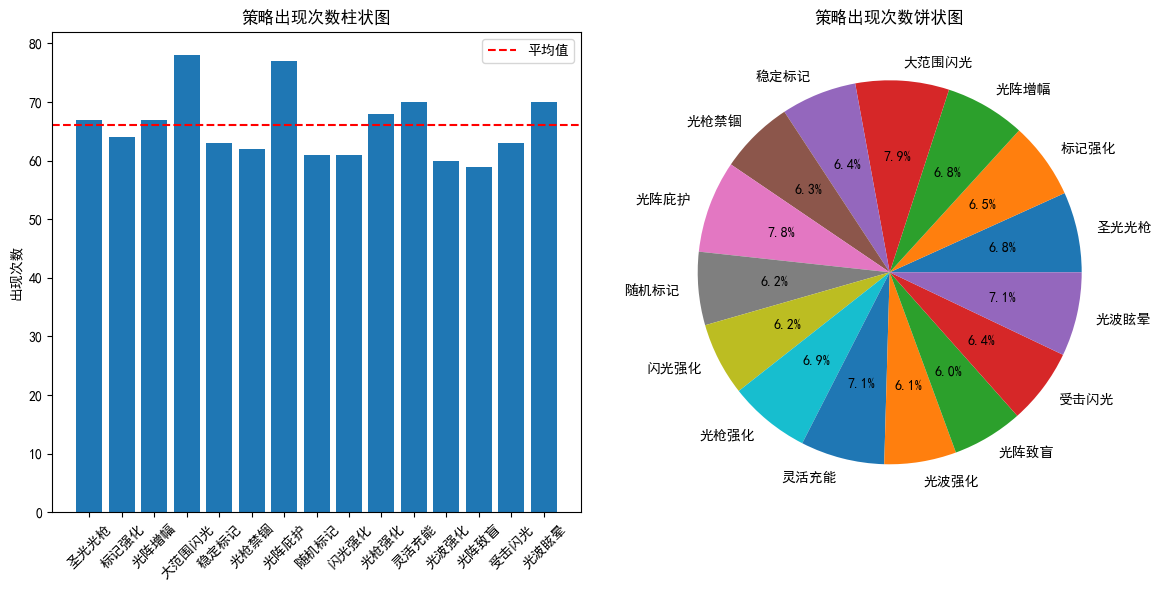

卡方统计量: 7.212121212121211, p 值: 0.9262249181539188
数据可能来自均匀分布或离散型概率分布


In [9]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_5个一阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带有五个基础策略，进入光属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 继续验证...

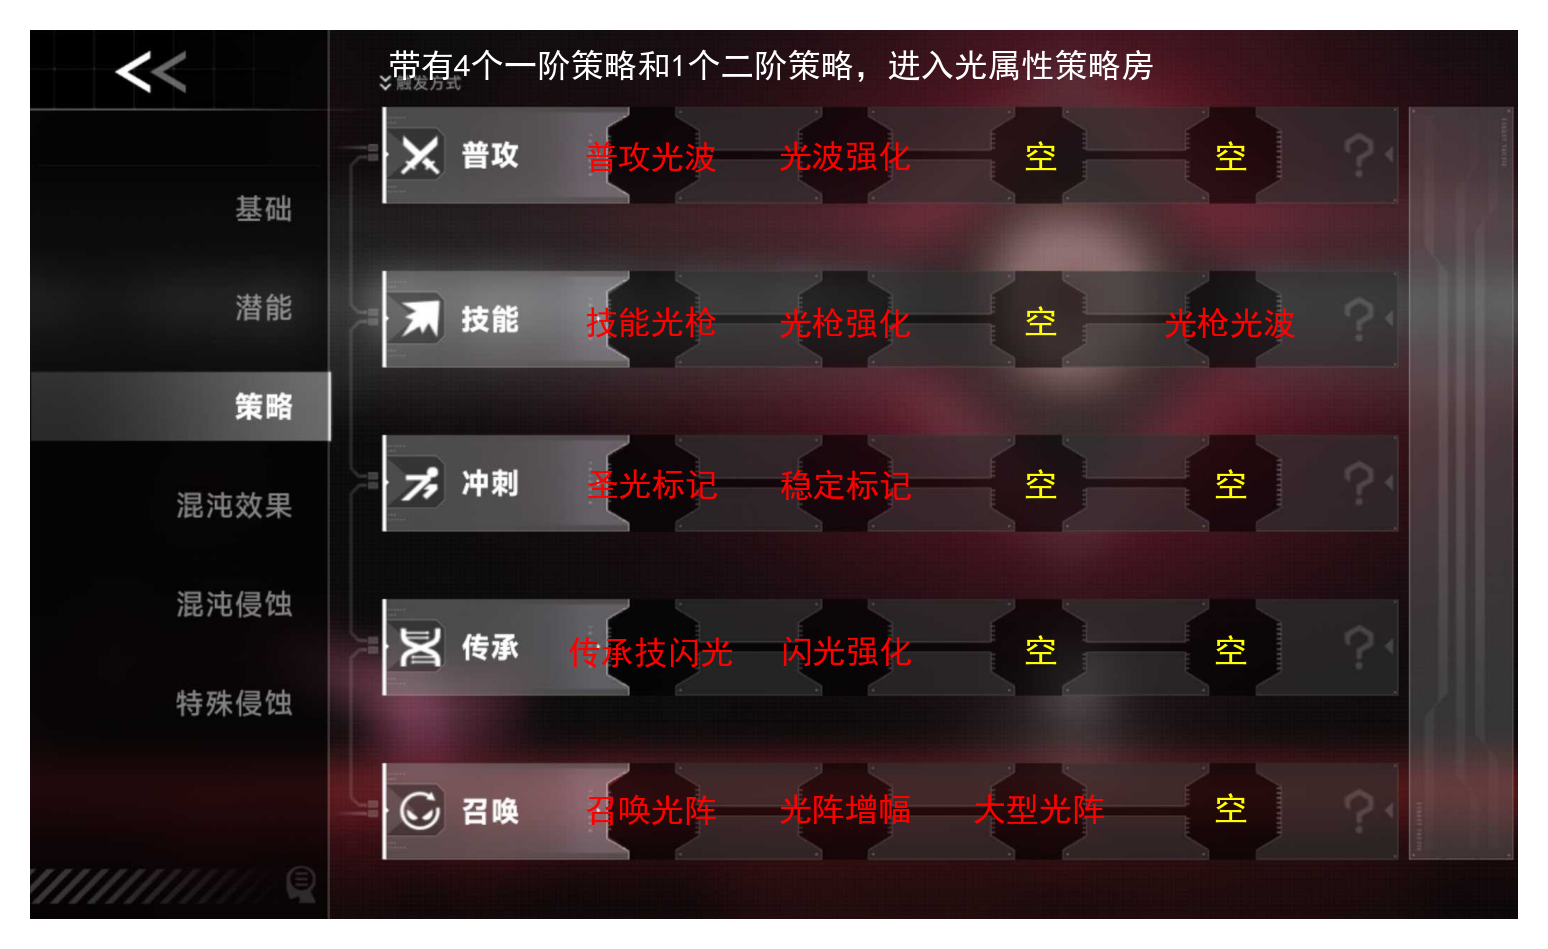

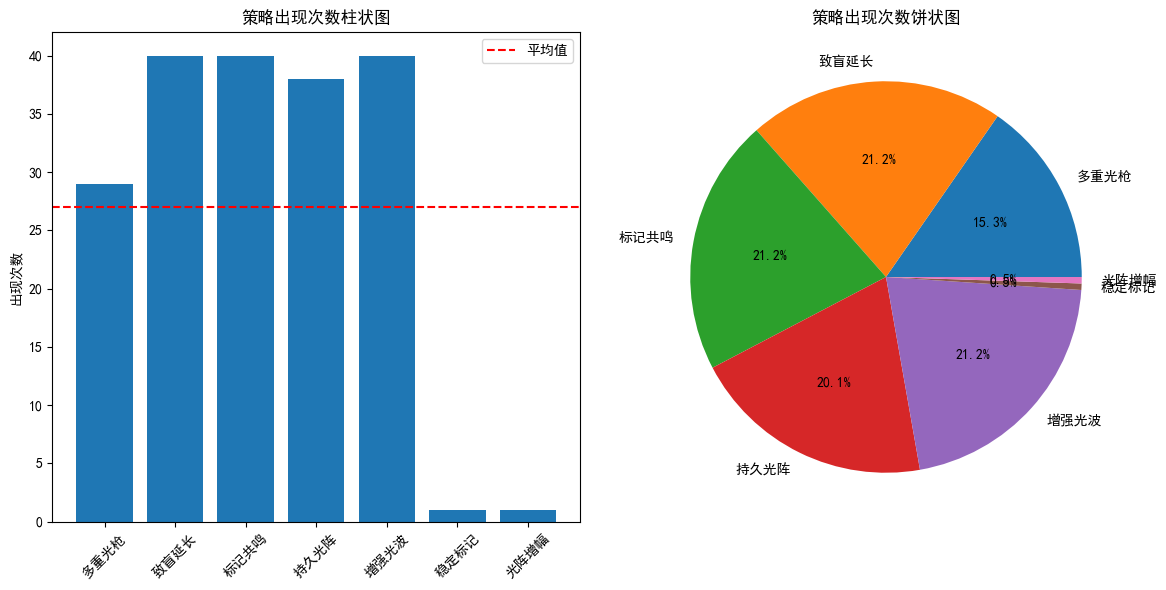

卡方统计量: 73.48148148148148, p 值: 7.881242244521279e-14
数据不太可能来自均匀分布或离散型概率分布。


In [10]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_4个二阶1个红.txt")
strategies = list(chain(*strategies))
utils.draw_status('带有4个一阶策略和1个二阶策略，进入光属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

经观测，少量的 稳定标记 和 光阵增幅 是升级，剔除出数据集。


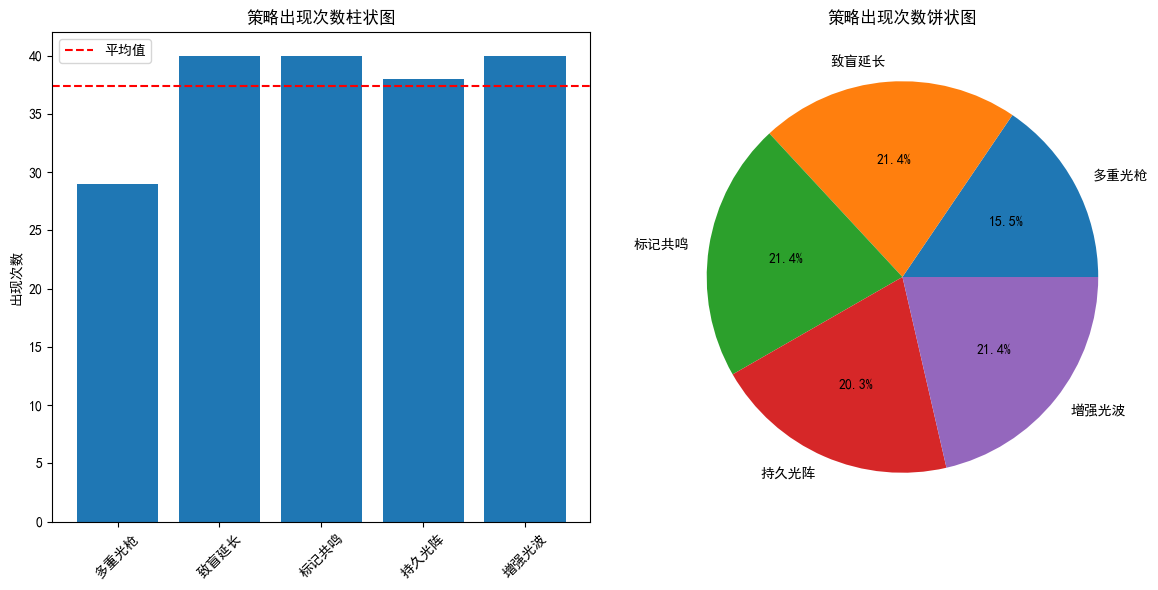

剔除策略升级
卡方统计量: 2.438502673796792, p 值: 0.6556806428350969
数据可能来自均匀分布或离散型概率分布


In [11]:
current_strategies = list(chain(*current_strategies))
names = [x.name for x in strategies if x.name not in current_strategies]
utils.plot_element_count(names)
print("剔除策略升级")
chi2, p = utils.test_uniform_distribution(list(Counter(names).values()))

# 继续验证...

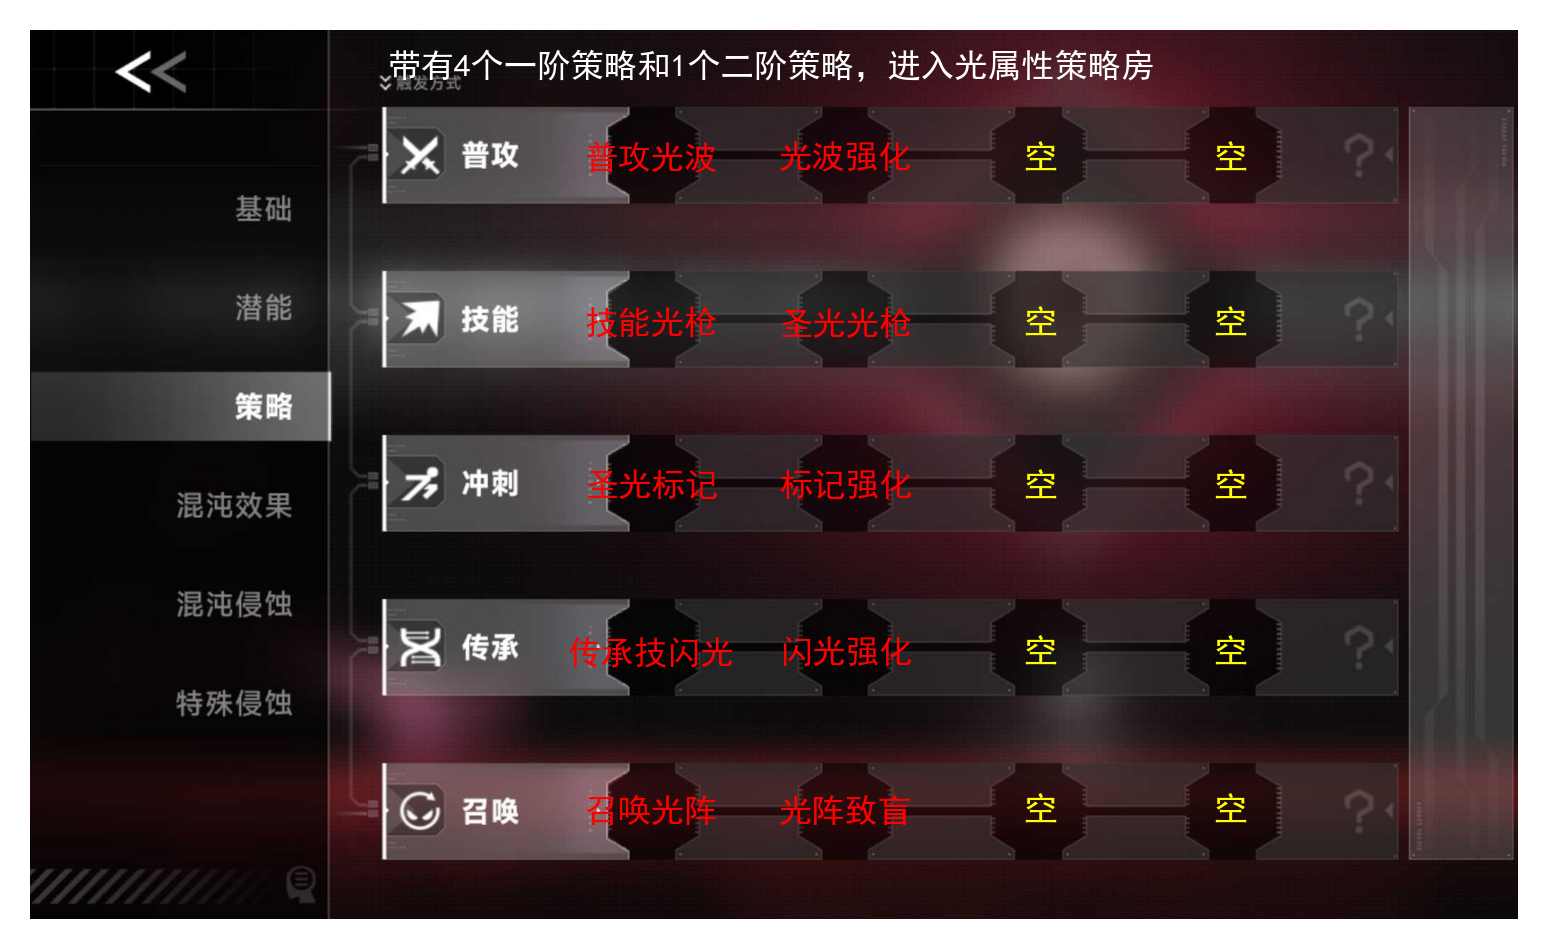

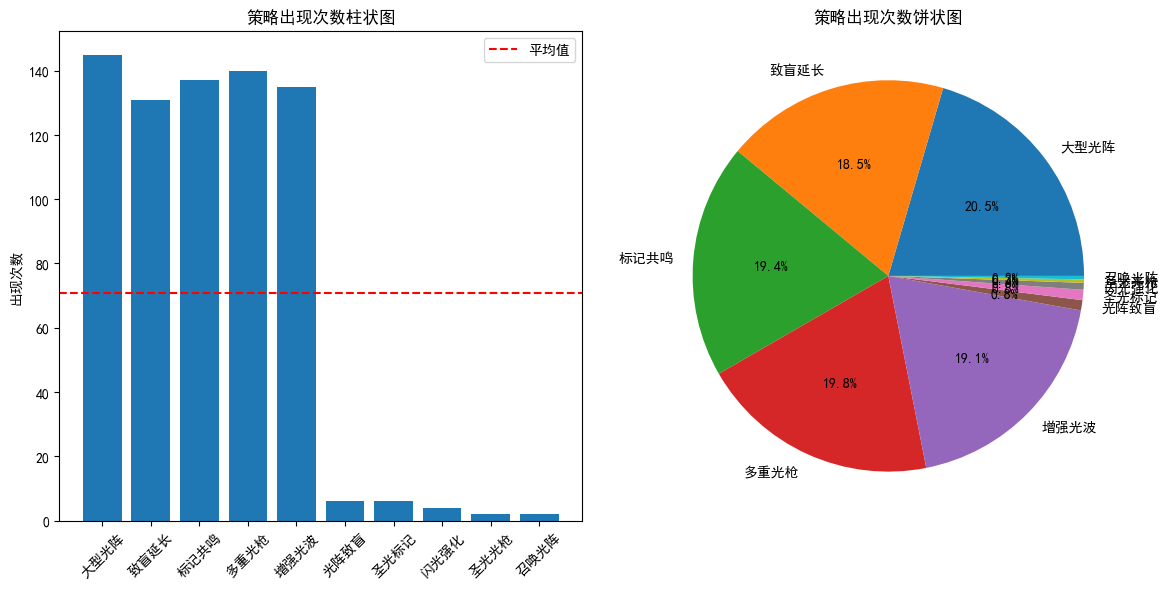

卡方统计量: 632.0564971751413, p 值: 2.7472177832007403e-130
数据不太可能来自均匀分布或离散型概率分布。


In [12]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_5个二阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带有4个一阶策略和1个二阶策略，进入光属性策略房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

经观测，少量的数据是升级，剔除出数据集。

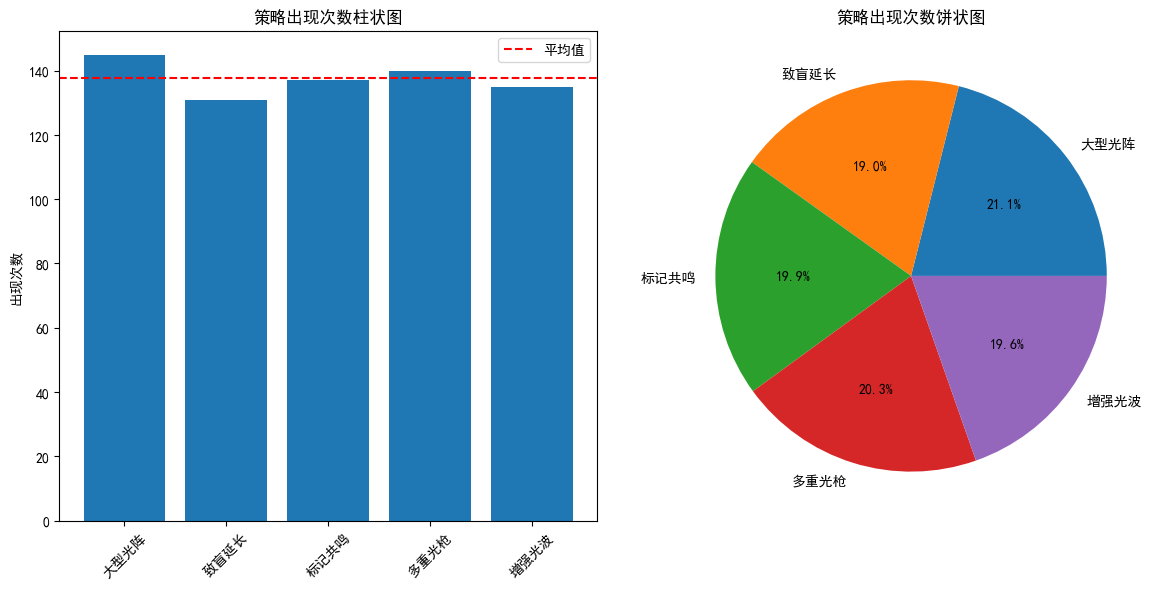

剔除策略升级
卡方统计量: 0.8081395348837209, p 值: 0.9373535270449542
数据可能来自均匀分布或离散型概率分布


In [13]:
current_strategies = list(chain(*current_strategies))
names = [x.name for x in strategies if x.name not in current_strategies]
utils.plot_element_count(names)
print("剔除策略升级")
chi2, p = utils.test_uniform_distribution(list(Counter(names).values()))

# 验证已存在的红策略是否对其他位置有影响

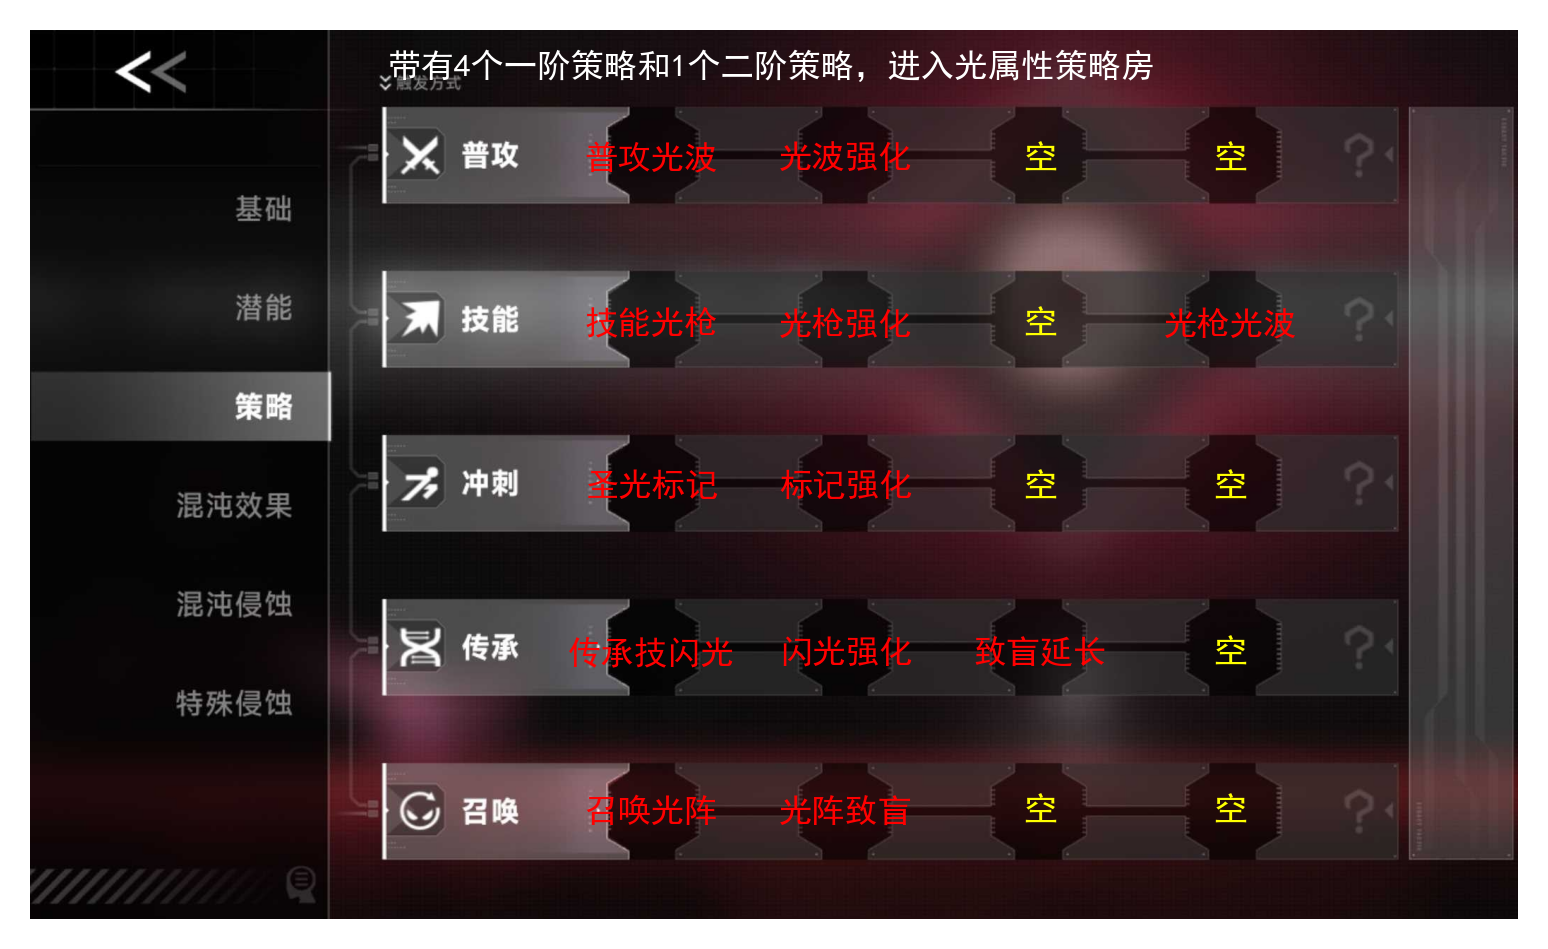

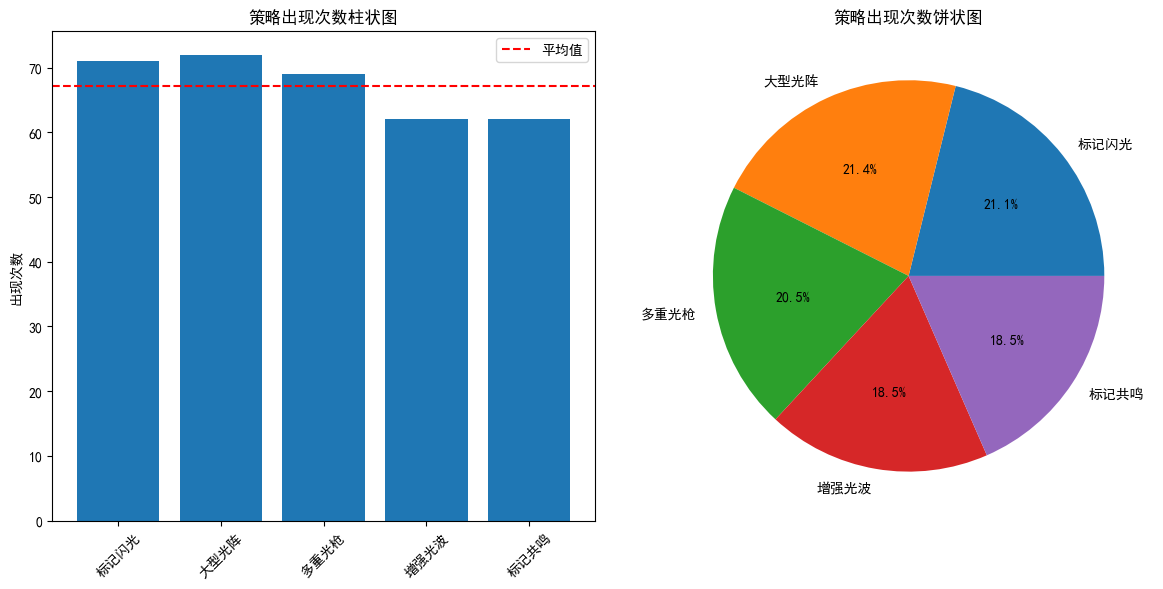

剔除策略升级
卡方统计量: 1.4107142857142856, p 值: 0.8423307003352274
数据可能来自均匀分布或离散型概率分布


In [14]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_4个二阶1个红_v2.txt")
utils.draw_status('带有4个一阶策略和1个二阶策略，进入光属性策略房', current_strategies)
strategies = list(chain(*strategies))
current_strategies = list(chain(*current_strategies))
names = [x.name for x in strategies if x.name not in current_strategies]
utils.plot_element_count(names)
print("剔除策略升级")
chi2, p = utils.test_uniform_distribution(list(Counter(names).values()))

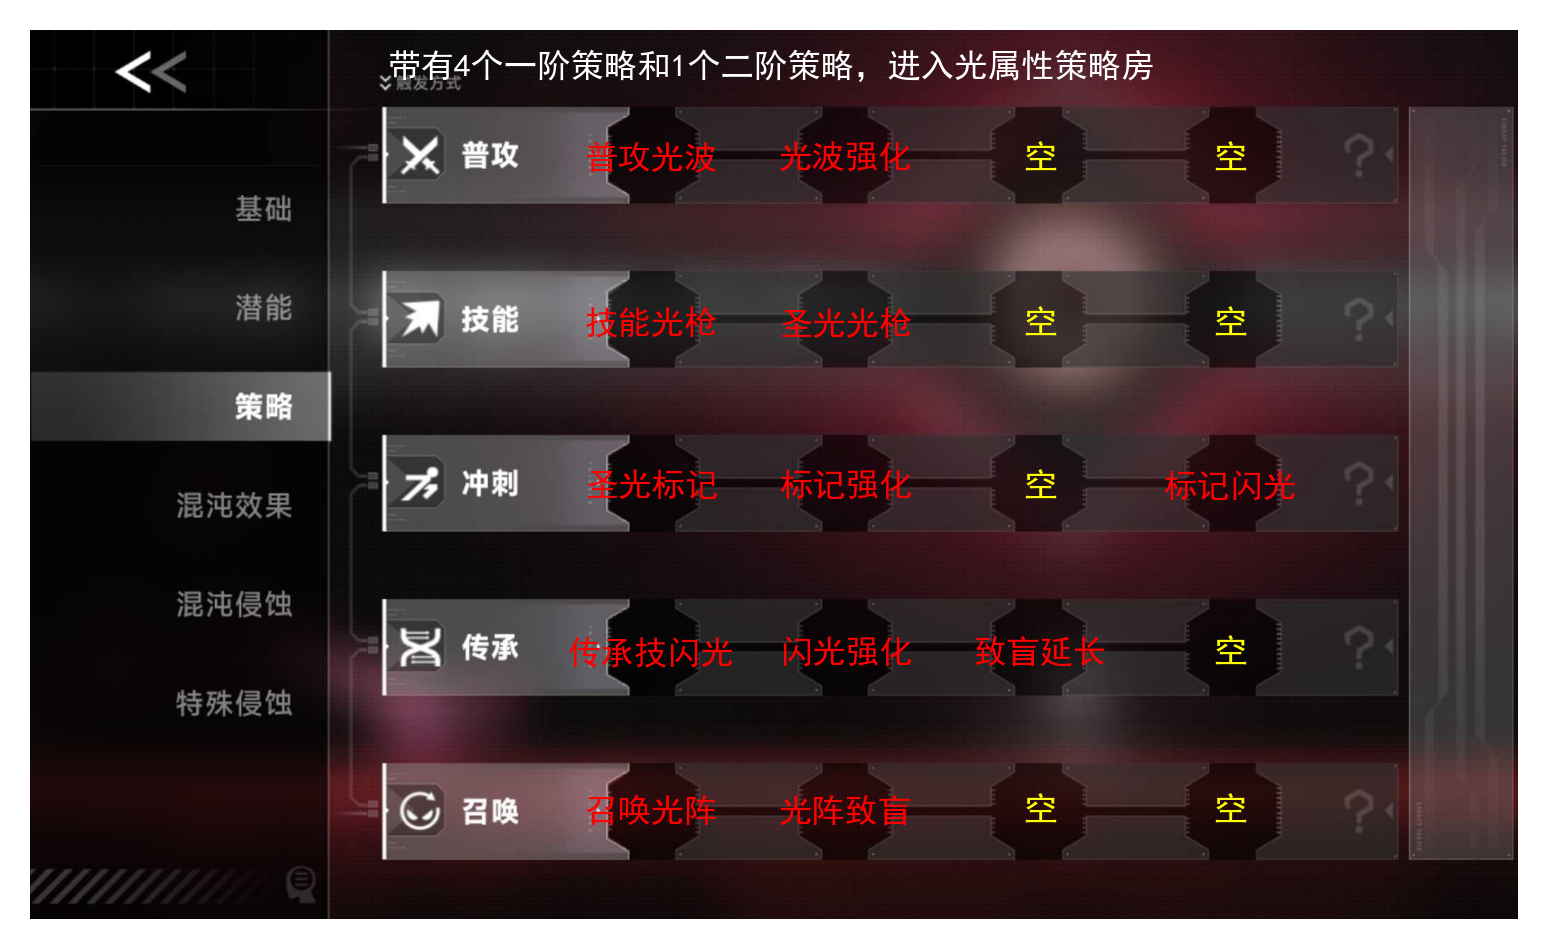

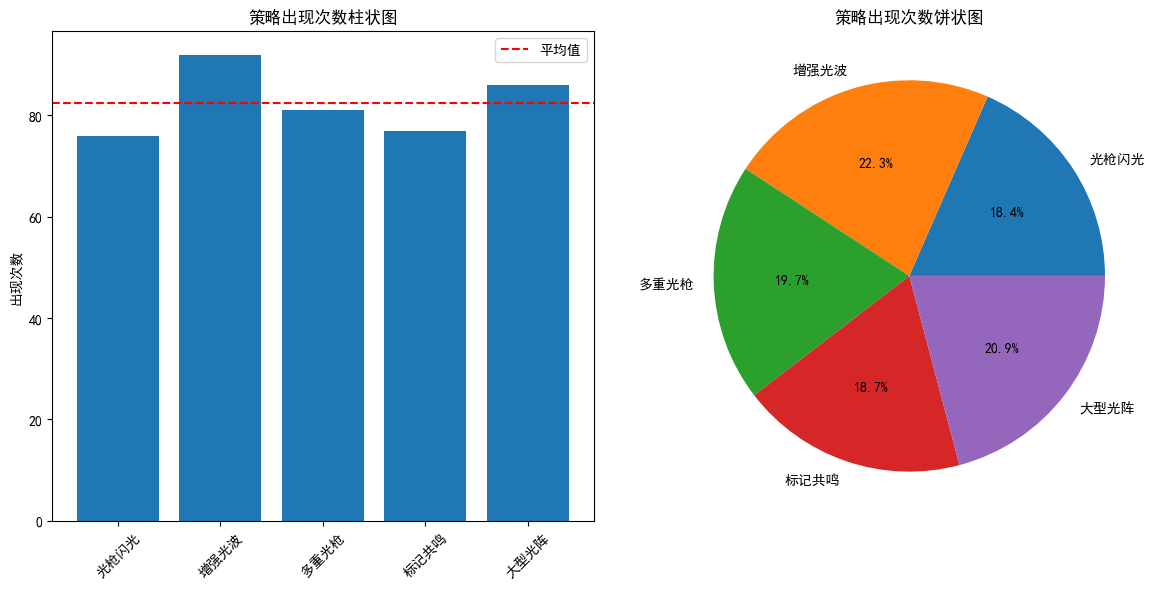

剔除策略升级
卡方统计量: 2.1504854368932036, p 值: 0.7081037907987424
数据可能来自均匀分布或离散型概率分布


In [15]:
current_strategies, strategies = utils.parse_file("data/策略房/光系测试_4个二阶1个红_v3.txt")
utils.draw_status('带有4个一阶策略和1个二阶策略，进入光属性策略房', current_strategies)
strategies = list(chain(*strategies))
current_strategies = list(chain(*current_strategies))
names = [x.name for x in strategies if x.name not in current_strategies]
utils.plot_element_count(names)
print("剔除策略升级")
chi2, p = utils.test_uniform_distribution(list(Counter(names).values()))

# 最终结论

## 苍翼第一定律：均衡定律

策略房内，任何可获得的策略（基础策略、一阶策略、二阶策略、红策略）之间，概率相等。

## 苍翼第二定律：替换定律

策略房内，当存在可替换的基础策略时，可替换策略作为一个整体加入卡池，遵循策略房第一定律，可替换策略内部概率相等。

> 特殊的，如果只有一个可获得策略时，第一个格子必然是可获得策略，且后两个格子均为可替换策略。
>> 更特殊的，如果没有某属性的可获得策略时，该属性的策略房将不会出现。

## 其他无关紧要的tips：

当可获得策略小于3时，必然出现策略升级。

当可获得策略大于3时，仍然会有较小的概率出现策略升级，不计入统计范围。